In [1]:
from quark import Task
token = 'Please Insert your token here (SQC Lab - Quafu)'
tmgr = Task(token)
tmgr.status()

{'Baihua': 1,
 'Yudu': 'Calibrating',
 'Dongling': 2,
 'Haituo': 'Calibrating',
 'Baiwang': 15,
 'Fenghuang': 1,
 'Haituo-2': 'Maintenance',
 'Hongluo': 'Calibrating',
 'Jiu': 'Maintenance',
 'Ling': 'Maintenance',
 'Lingkai-1': 'Calibrating',
 'Lingkai-2': 'Calibrating',
 'Miaofeng': 'Maintenance',
 'Shenglian': 'Calibrating',
 'Xiang': 'Maintenance'}

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quafu import QuantumCircuit, simulate

In [3]:
# 1. Creating 2 Qubits

qc = QuantumCircuit(2)

# 2. Applying Operators

# HZ(0) and HS(1)
qc.h(0)
qc.z(0)
qc.h(1)
qc.s(1)
qc.barrier()

# Permutation Operator

#P1+

qc.cnot(1,0)
qc.x(1)

# SH(1)
qc.s(1)
qc.h(1)

# Measurement(1)
qc.measure([1],  [1])
qc.measures

{1: 1}

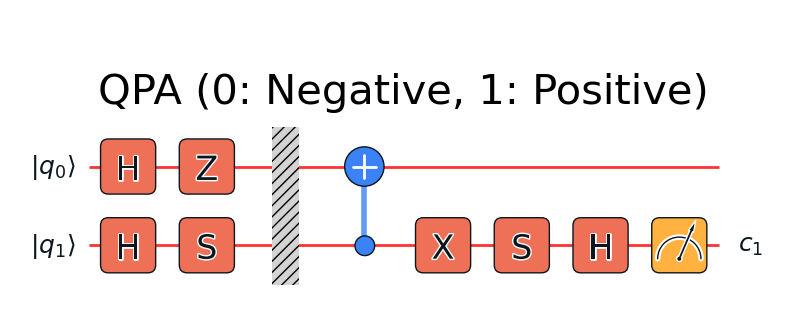

In [4]:
# 3. Drawing circuit diagram

qc.plot_circuit(title="QPA (0: Negative, 1: Positive)")

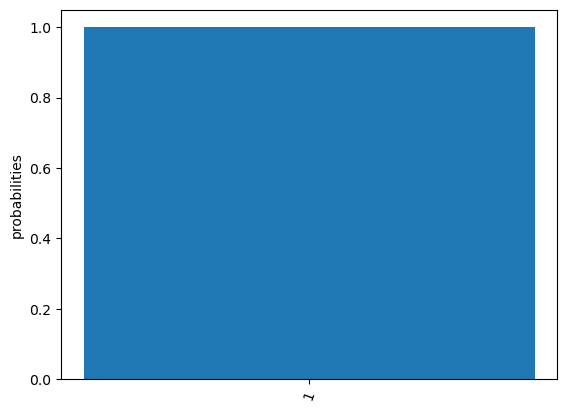

In [5]:
# 4. Simulation and Graph

simu_res = simulate(qc)
simu_res.plot_probabilities()

In [6]:
# Exporting as OpenQASM

qasm = qc.to_openqasm()
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
z q[0];
h q[1];
s q[1];
barrier q[0],q[1];
cx q[1],q[0];
x q[1];
s q[1];
h q[1];
measure q[1] -> meas[1];



In [7]:
# Preparing the task
task = {'chip': 'Baihua',  # chip name
        'name': 'QPA',  # task name
        'circuit':qasm, # qasm
        'compile':True
        }

In [8]:
# Sending our task to Quafu's quantum computer
tid = tmgr.run(task)

In [10]:
# Task status
tmgr.status(tid)

'Finished'

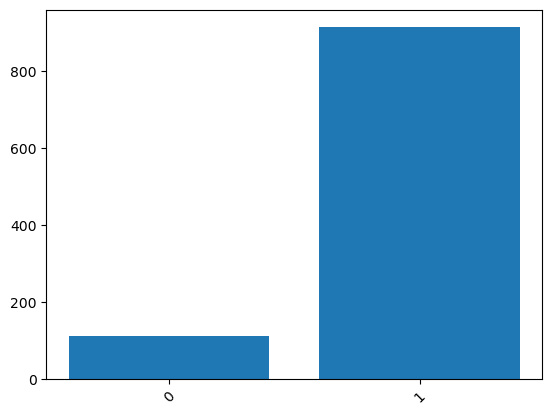

In [11]:
# Graph: The results from quantum computer
res = tmgr.result(tid)
data = res['count']
bases = sorted(data)
count = [data[base] for base in bases]

plt.bar(bases, count)
ticks = plt.xticks(rotation=45)

In [ ]:
Operator	THE GATES
P0+​	    (Empty Circuit) (I)
P1+​	    CNOT(q1​,q0​), then X(q1​)
P2+​	    X(q0​)
P3+​	    CNOT(q1​,q0​), then X(q1​),X(q0​)    
P0−​	    CNOT(q1​,q0​)
P1−​	    X(q1​)
P2−​	    CNOT(q1​,q0​), then X(q0​)
P3−​	    X(q1​),X(q0​)

In [ ]:
"""

#P0+

#Identity Operator (empty)

--------------------

#P1+

qc.cnot(1,0)
qc.x(1)

--------------------

#P2+

qc.x(0)

--------------------

#P3+

qc.cnot(1,0)
qc.x(0)
qc.x(1)

--------------------

#P0-

qc.cnot(1,0)

--------------------

#P1-

qc.x(1)

--------------------

#P2-

qc.cnot(1,0)
qc.x(0)

--------------------

#P3-

qc.x(0)
qc.x(1)

--------------------

"""